In [2]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report, precision_recall_curve, average_precision_score

# load the saved model
with open('../models/log_reg_breast_cancer.pkl', 'rb') as f:
    model = pickle.load(f)

# load data
data = load_breast_cancer(as_frame=True)
df = data.frame
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Model loaded successfully!")

Model loaded successfully!


In [3]:
sample = X_test.iloc[:5]
predictions = model.predict(sample)
actual = y_test.iloc[:5].values

for i, (pred, act) in enumerate(zip(predictions, actual)):
    pred_label = data.target_names[pred]
    actual_label = data.target_names[act]
    match = "✓" if pred == act else "✗"
    print(f"Sample {i+1} | Predicted: {pred_label} | Actual: {actual_label} {match}")

Sample 1 | Predicted: malignant | Actual: malignant ✓
Sample 2 | Predicted: benign | Actual: benign ✓
Sample 3 | Predicted: malignant | Actual: malignant ✓
Sample 4 | Predicted: malignant | Actual: benign ✗
Sample 5 | Predicted: malignant | Actual: malignant ✓


In [4]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

              precision    recall  f1-score   support

   Malignant       0.93      0.98      0.95        42
      Benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



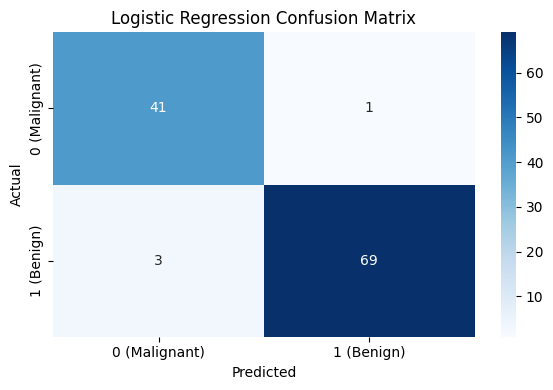

In [5]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0 (Malignant)', '1 (Benign)'],
            yticklabels=['0 (Malignant)', '1 (Benign)'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

The model correctly identified 41 out of 42 malignant cases, missing only 1. Of the 72 benign cases, 3 were incorrectly flagged as malignant. In a clinical setting, the single missed malignant case is the most critical error, and the model does well to keep that number low.

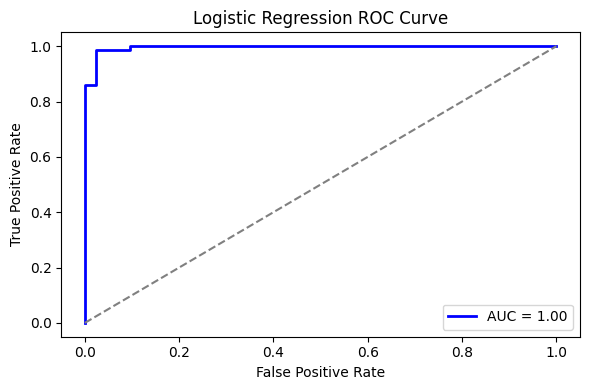

In [6]:
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

The model achieved an AUC of 1.00, indicating near perfect separation between malignant and benign cases. The curve hugs the top left corner closely, meaning the model maintains high true positive rate while keeping false positives very low across all thresholds.

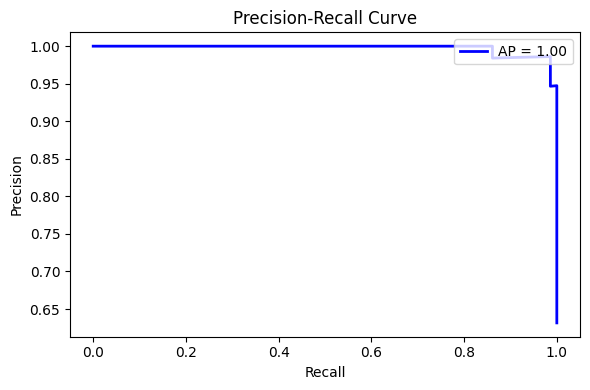

In [7]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, color='blue', lw=2, label=f"AP = {avg_precision:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

The precision-recall curve shows an average precision of 1.00, staying near perfect precision across almost the entire recall range. The sharp drop at the far right is expected behavior at extreme thresholds and does not affect real world performance.

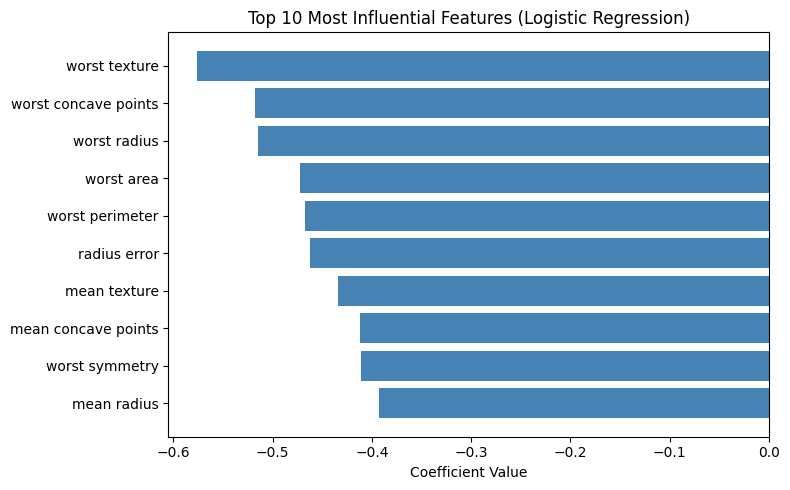

In [9]:
feature_names = X.columns
coefficients = model.named_steps['classifier'].coef_[0]

feat_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).reindex(pd.Series(coefficients).abs().sort_values(ascending=False).index)

top10 = feat_importance.head(10)

plt.figure(figsize=(8, 5))
colors = ['steelblue' for _ in top10['Coefficient']]
plt.barh(top10['Feature'], top10['Coefficient'], color=colors)
plt.xlabel("Coefficient Value")
plt.title("Top 10 Most Influential Features (Logistic Regression)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

All top 10 features have negative coefficients, meaning higher values in these features push the model toward predicting malignant (class 0). This lines up with what we found in the EDA, where size related measurements like worst radius, worst perimeter, and worst area were among the strongest predictors. This makes clinical sense as malignant tumors tend to be larger and more irregular.